In [ ]:
import os
from google.colab import drive, userdata

# --- CONFIGURATION ---
REPO_NAME = "HeliosAI-v2"  # Change this to your repo name
GIT_USERNAME = userdata.get('GITHUB_USER')
GIT_EMAIL = userdata.get('GITHUB_EMAIL')
TOKEN = userdata.get('GITHUB_TOKEN')

# 1. Mount Google Drive for persistence
drive.mount('/content/drive')
PROJECT_PATH = f"/content/drive/MyDrive/{REPO_NAME}"

# 2. Configure Git Identity
!git config --global user.email "{GIT_EMAIL}"
!git config --global user.name "{GIT_USERNAME}"

# 3. Clone or Pull
if not os.path.exists(PROJECT_PATH):
    print(f"🚀 Cloning {REPO_NAME} into Google Drive...")
    # Navigate to MyDrive and clone
    %cd /content/drive/MyDrive
    repo_url = f"https://{TOKEN}@github.com/{GIT_USERNAME}/{REPO_NAME}.git"
    !git clone {repo_url}
    %cd {REPO_NAME}
else:
    print(f"🔄 {REPO_NAME} already exists. Pulling latest changes...")
    %cd {PROJECT_PATH}
    !git pull

print(f"\n✅ Setup complete! Current directory: {os.getcwd()}")

In [ ]:
def git_push_notebooks(message="update notebook"):
    """Only stages and pushes .ipynb files to GitHub"""
    !git add *.ipynb
    !git commit -m "{message}"
    !git push origin main
    print("🚀 Notebooks pushed successfully!")

# Usage:
# git_push_notebooks("Finished the data cleaning section")

In [ ]:
git_push_notebooks(message="prepare even better dataset")

[main 8fa2666] prepare even better dataset
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite HeliosAI.ipynb (93%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 2.07 KiB | 15.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/5heron/HeliosAI-v2.git
   a1522be..8fa2666  main -> main
🚀 Notebooks pushed successfully!


In [ ]:
!pip install pvlib xgboost lightgbm catboost seaborn requests openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [ ]:
#!/usr/bin/env python3
"""
perfected_master_pipeline_v5.5.py
**FULLY COMPLIANT WITH FINAL MASTER REFERENCE CHECKLIST v1 + User Enhancements**

v5.5 Enhancements (per user request):
1. Dewpoint features: Added "DewPt" to WEATHER_COLS whitelist; computed dewpoint (alias for DewPt) + dewpoint_depression = TempOut - DewPt
   (Cloud formation correlation boost)
2. Solar time features: Added day_of_year_sin / day_of_year_cos (cyclic seasonal encoding; preserves physics)
3. POA ratio: Added poa_ratio = SolarRad / poa_global_safe (cloud attenuation proxy; powerful for generalization)
- All in new add_engineered_features() for clarity
- Updated final_select_and_qc core whitelist (~28 feats total)
- Retained all prior fixes: no errors/warnings, hourly handling (3600s freq → 1-step lags), etc.

Expected R² gain: +0.02–0.05 from these (dewpoint depression + seasonal + poa_ratio)
Total expected: 0.77–0.90
"""

import zipfile
import requests
from pathlib import Path
import numpy as np
import pandas as pd
import pvlib
from pvlib.location import Location
from pvlib.irradiance import get_total_irradiance
import re
import gc
from typing import List

# ---------------- Config (Master Reference aligned + User Enhancements) ----------------
BASE_DIR = Path("data")
BASE_DIR.mkdir(exist_ok=True)
FOLDS_DIR = Path("folds")
FOLDS_DIR.mkdir(exist_ok=True)

PV_URL = "https://data.london.gov.uk/download/photovoltaic-pv-solar-panel-energy-generation-data-2nlqm/81fb6b31-f6b2-4e12-b054-090319faec7b/PV%20Data.zip"
WX_URL = "https://data.london.gov.uk/download/photovoltaic-pv-solar-panel-energy-generation-data-2nlqm/b4a7e790-8cb8-451c-b828-c4c5d8445705/Weather%20Data%202014-11-30.xlsx"

PV_ZIP = BASE_DIR / "PV_Data.zip"
PV_FOLDER = BASE_DIR / "PV_Data"
WX_FILE = BASE_DIR / "Weather.xlsx"

TZ = "Europe/London"
LAT, LON, ALT = 51.5, -0.1, 50
TILT, AZIMUTH = 30, 180

MERGE_TOL = "30min"          # Master Reference
LAGS_MINUTES = [60, 120, 180]  # Adaptive persistence (for hourly → shifts ~[1,1,1])
LOW_IRR_THRESHOLD = 25.0     # W/m²
PV_PER_KW_MAX = 1.3
PV_PER_KW_MIN = 0.0

# Strict whitelists (updated: + DewPt for dewpoint features)
PV_CORE_COLS = ["t_date", "t_time", "SerialNo", "P_GEN_MAX", "Apparent PV Size", "System Size (kW)"]
WEATHER_COLS = ["SolarRad", "TempOut", "OutHum", "WindSpeed", "RainRate", "Bar", "DewPt"]  # + DewPt

DEFAULT_MEDIAN_SIZE_KW = 3.5

# ---------------- Utilities ----------------
def download_and_extract():
    if not PV_ZIP.exists():
        print("Downloading PV ZIP...")
        PV_ZIP.write_bytes(requests.get(PV_URL, timeout=60).content)
    if not PV_FOLDER.exists():
        print("Extracting PV ZIP...")
        with zipfile.ZipFile(PV_ZIP, "r") as z:
            z.extractall(PV_FOLDER)
        for zpath in PV_FOLDER.rglob("*.zip"):
            try:
                with zipfile.ZipFile(zpath, "r") as z:
                    z.extractall(PV_FOLDER)
                zpath.unlink()
            except Exception:
                pass
    if not WX_FILE.exists():
        print("Downloading Weather XLSX...")
        WX_FILE.write_bytes(requests.get(WX_URL, timeout=60).content)
    print("Download/extract complete.")

def downcast_floats(df: pd.DataFrame) -> pd.DataFrame:
    float_cols = df.select_dtypes("float64").columns
    if len(float_cols) > 0:
        df[float_cols] = df[float_cols].astype("float32")
    return df

def find_pv_csvs():
    pv_files = list(set(PV_FOLDER.rglob("*HourlyData*Endpoint*.csv")))
    print(f"Found {len(pv_files)} hourly PV CSVs (whitelisted loading)")
    return pv_files

def load_pv_data(pv_files: List[Path]) -> pd.DataFrame:
    pv_dfs = []
    for f in pv_files:
        print(f"Loading {f.name}")
        df = pd.read_csv(
            f,
            usecols=lambda c: c.strip() in PV_CORE_COLS,  # Strict Master Reference
            low_memory=False,
            dtype={"SerialNo": "str", "P_GEN_MAX": "float32"}
        )
        df.columns = df.columns.str.strip()
        if "t_date" in df.columns and "t_time" in df.columns:
            df["datetime"] = pd.to_datetime(
                df["t_date"].astype(str).str.strip() + " " + df["t_time"].astype(str).str.strip(),
                errors="coerce"
            )
        df = df.dropna(subset=["datetime"]).reset_index(drop=True)
        pv_dfs.append(df)
        gc.collect()
    pv = pd.concat(pv_dfs, ignore_index=True) if pv_dfs else pd.DataFrame()
    # Fix potential dupes from extraction/concat
    serial_col = next((c for c in pv.columns if "serial" in c.lower()), None)
    if serial_col:
        pv = pv.drop_duplicates(subset=[serial_col, "datetime"])
    pv = downcast_floats(pv)
    print(f"PV loaded & downcast (deduped): {pv.shape}")
    return pv

def find_and_load_device():
    dev_candidates = list(PV_FOLDER.rglob("*deviceList*.xlsx")) + list(PV_FOLDER.rglob("*deviceList*.xls"))
    if not dev_candidates:
        return pd.DataFrame()
    dev = pd.read_excel(dev_candidates[0])
    dev.columns = dev.columns.str.strip()
    # Only SerialNo + size (Master Reference)
    size_pat = re.compile(r"size|capacity|kw|g83", re.I)
    keep_cols = ["Serial Number"] + [c for c in dev.columns if size_pat.search(c)]
    return dev[keep_cols]

def infer_pv_frequency(pv: pd.DataFrame, wx: pd.DataFrame = None) -> float:
    """Dynamic freq inference (global/per-serial/weather fallback) from v3_fixed_freq."""
    diffs = pv.sort_values("datetime")["datetime"].diff().dt.total_seconds().dropna()
    diffs_nonzero = diffs[diffs > 0]
    if len(diffs_nonzero) > 0:
        return float(diffs_nonzero.median())

    serial_col = next((c for c in pv.columns if "serial" in c.lower()), None)
    medians = []
    if serial_col:
        for _, g in pv.groupby(serial_col):
            d = g.sort_values("datetime")["datetime"].diff().dt.total_seconds().dropna()
            d = d[d > 0]
            if len(d) > 0:
                medians.append(d.median())
    if medians:
        return float(np.median(medians))

    if wx is not None:
        wdiffs = wx.sort_values("datetime")["datetime"].diff().dt.total_seconds().dropna()
        wdiffs = wdiffs[wdiffs > 0]
        if len(wdiffs) > 0:
            return float(wdiffs.median())

    print("Freq inference failed -> defaulting to 3600s (1h)")
    return 3600.0

def parse_and_localize(df, date_col, time_col):
    dt = pd.to_datetime(
        df[date_col].astype(str).str.strip() + " " + df[time_col].astype(str).str.strip(),
        errors="coerce"
    )
    df = df.assign(datetime=dt).dropna(subset=["datetime"]).sort_values("datetime")
    local = df["datetime"].dt.tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")
    df = df.loc[~local.isna()].copy()
    df["datetime"] = local.dt.tz_convert("UTC")
    return df

def prepare_weather(wx: pd.DataFrame, pv_freq_seconds: float) -> pd.DataFrame:
    """Global site-level interpolation + adaptive resample BEFORE merge (Master Reference + freq fix)."""
    for c in WEATHER_COLS:
        if c in wx.columns:
            # Fix FutureWarning: astype(str) before replace
            temp = wx[c].astype(str).replace("---", np.nan)
            wx[c] = pd.to_numeric(temp, errors="coerce")
    wx = downcast_floats(wx)
    wx = wx.set_index("datetime").sort_index()
    if wx.index.duplicated().any():
        wx = wx[~wx.index.duplicated(keep="first")]

    sec = int(max(1, round(pv_freq_seconds)))
    freq_str = f"{sec}s"  # lowercase 's' to fix deprecation
    try:
        wx[WEATHER_COLS] = wx[WEATHER_COLS].resample(freq_str).interpolate(method="time").ffill().bfill()
    except Exception:
        full_idx = pd.date_range(start=wx.index.min(), end=wx.index.max(), freq=freq_str, tz="UTC")
        wx = wx.reindex(full_idx)
        for c in WEATHER_COLS:
            if c in wx.columns:
                wx[c] = wx[c].interpolate(method="time").ffill().bfill()
    wx = wx.reset_index().rename(columns={"index": "datetime"})
    print(f"Weather resampled/interpolated globally to {freq_str} (rows: {len(wx)})")
    return wx

def vectorized_weather_merge(pv: pd.DataFrame, wx: pd.DataFrame) -> pd.DataFrame:
    """Vectorized merge_asof WITHOUT 'by' (weather global/site-level; fixes KeyError)."""
    pv = pv.sort_values("datetime").reset_index(drop=True)  # ONLY datetime for merge_asof (fixes ValueError)
    wx = wx.sort_values("datetime").reset_index(drop=True)
    merged = pd.merge_asof(
        pv, wx,
        on="datetime",
        tolerance=pd.Timedelta(MERGE_TOL),
        direction="nearest"
    )
    preservation = len(merged) / len(pv) * 100
    print(f"Vectorized weather merge (global): {len(merged)} rows ({preservation:.1f}% preserved)")
    if preservation < 95:
        print("WARNING: Consider increasing MERGE_TOL")
    return merged

# ---------------- Solar Physics (NO clipping + Array Inputs Fix) ----------------
def add_solar_physics(df: pd.DataFrame) -> pd.DataFrame:
    if df["datetime"].dt.tz is None:
        df["datetime"] = df["datetime"].dt.tz_localize("UTC")
    # Ensure clean DatetimeIndex
    times_local = pd.DatetimeIndex(df["datetime"]).tz_convert(TZ)
    site = Location(LAT, LON, TZ, ALT)
    solpos = site.get_solarposition(times_local)
    clearsky = site.get_clearsky(times_local, model="ineichen")

    # Assign arrays
    df["solar_zenith"] = solpos["zenith"].values
    df["solar_azimuth"] = solpos["azimuth"].values
    df["air_mass"] = pvlib.atmosphere.get_relative_airmass(solpos["zenith"].values)  # .values fix

    df["cs_ghi"] = clearsky["ghi"].values
    df["cs_dni"] = clearsky["dni"].values
    df["cs_dhi"] = clearsky["dhi"].values

    # POA with explicit arrays (fixes potential series length/index mismatch)
    poa = get_total_irradiance(
        surface_tilt=TILT, surface_azimuth=AZIMUTH,
        solar_zenith=solpos["zenith"].values,  # .values fix
        solar_azimuth=df["solar_azimuth"].values,
        dni=df["cs_dni"].values, ghi=df["cs_ghi"].values, dhi=df["cs_dhi"].values
    )
    # poa["poa_global"] is ndarray → no .values
    df["poa_global"] = poa["poa_global"]

    df["is_day"] = (90 - solpos["zenith"].values > 0).astype(int)

    mask = (df["is_day"] == 0) | (df["cs_ghi"] <= 0)
    for c in ["cs_ghi", "cs_dni", "cs_dhi", "poa_global"]:
        df.loc[mask, c] = 0.0

    print("Solar physics added (raw zenith, no clipping, array inputs)")
    return downcast_floats(df)

# ---------------- Thermal Physics ----------------
def add_thermal_physics(df: pd.DataFrame) -> pd.DataFrame:
    if "TempOut" in df.columns and "poa_global" in df.columns:
        df["cell_temp"] = df["TempOut"] + ((45 - 20) / 800.0) * df["poa_global"]
    else:
        df["cell_temp"] = df.get("TempOut", 25.0)
    df["temp_loss"] = 1 - 0.004 * (df["cell_temp"] - 25).clip(lower=0.0)
    print("Thermal physics added")
    return downcast_floats(df)

# ---------------- Temporal Encoding (Hourly + Seasonal Cyclic) ----------------
def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    local = pd.DatetimeIndex(df["datetime"]).tz_convert(TZ)
    hour_f = local.hour + local.minute / 60.0
    df["Hour_sin"] = np.sin(2 * np.pi * hour_f / 24)
    df["Hour_cos"] = np.cos(2 * np.pi * hour_f / 24)

    # User enhancement: Cyclic seasonal (day_of_year)
    doy_f = local.dayofyear
    df["day_of_year_sin"] = np.sin(2 * np.pi * doy_f / 365.25)
    df["day_of_year_cos"] = np.cos(2 * np.pi * doy_f / 365.25)

    print("Temporal features added (hourly + seasonal cyclic)")
    return df

# ---------------- Engineered Features (User Enhancements) ----------------
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    # User enhancement 1: Dewpoint features (cloud formation proxy)
    if "DewPt" in df.columns:
        df["dewpoint"] = df["DewPt"]  # Alias for clarity
        if "TempOut" in df.columns:
            df["dewpoint_depression"] = df["TempOut"] - df["dewpoint"]

    # User enhancement 3: POA ratio (cloud attenuation relative to theoretical)
    df["poa_global_safe"] = df["poa_global"].replace(0, np.nan)
    if "SolarRad" in df.columns:
        df["poa_ratio"] = (df["SolarRad"] / df["poa_global_safe"]).clip(0, 2).fillna(0)

    # Clearsky index (Master Reference)
    df["cs_ghi_safe"] = df["cs_ghi"].replace(0, np.nan)
    if "SolarRad" in df.columns:
        df["clearsky_index"] = (df["SolarRad"] / df["cs_ghi_safe"]).clip(0, 2).fillna(0)

    print("Engineered features added (dewpoint, poa_ratio, clearsky_index)")
    return downcast_floats(df)

# ---------------- Persistence + Rolling + Dynamics (Grouped + Adaptive) ----------------
def lag_shifts_from_freq_seconds(pv_freq_seconds: float, minutes_list: List[int]) -> List[int]:
    sec = max(1.0, float(pv_freq_seconds))
    return [max(1, int(round(m * 60.0 / sec))) for m in minutes_list]

def add_persistence_and_dynamics(df: pd.DataFrame, pv_freq_seconds: float) -> pd.DataFrame:
    serial_col = next((c for c in df.columns if "serial" in c.lower()), None)
    if serial_col:
        df = df.sort_values([serial_col, "datetime"]).reset_index(drop=True)
    else:
        df = df.sort_values("datetime").reset_index(drop=True)

    # Adaptive persistence lags
    shifts = lag_shifts_from_freq_seconds(pv_freq_seconds, LAGS_MINUTES)
    for shift in shifts:
        for base in ["pv_per_kw", "SolarRad"]:
            if base in df.columns:
                if serial_col:
                    df[f"{base}_lag{shift}"] = df.groupby(serial_col)[base].shift(shift)
                else:
                    df[f"{base}_lag{shift}"] = df[base].shift(shift)

    # Grouped rolling volatility
    for col, name in [("SolarRad", "irradiance_volatility"), ("clearsky_index", "cloud_volatility")]:
        if col in df.columns:
            if serial_col:
                df[name] = df.groupby(serial_col)[col].transform(
                    lambda x: x.rolling(window=3, min_periods=1).std()
                ).fillna(0.0)
            else:
                df[name] = df[col].rolling(window=3, min_periods=1).std().fillna(0.0)

    # Cloud dynamics (grouped diff)
    if "SolarRad" in df.columns:
        if serial_col:
            df["irradiance_grad"] = df.groupby(serial_col)["SolarRad"].diff().fillna(0.0)
        else:
            df["irradiance_grad"] = df["SolarRad"].diff().fillna(0.0)

    print(f"Persistence (adaptive shifts: {shifts}) + grouped dynamics added")
    return downcast_floats(df)

# ---------------- Target Normalization ----------------
def normalize_target(df: pd.DataFrame, dev_df: pd.DataFrame) -> pd.DataFrame:
    size_col = next((c for c in df.columns if re.search(r"apparent.*size|system.*size|capacity|kw", c, re.I)), None)
    if size_col and size_col in df.columns:
        df[size_col] = pd.to_numeric(df[size_col], errors="coerce")
        df = df[df[size_col] > 0].copy()
        df["pv_per_kw"] = df["P_GEN_MAX"] / df[size_col]
    else:
        median_size = DEFAULT_MEDIAN_SIZE_KW
        if not dev_df.empty:
            cand = [c for c in dev_df.columns if re.search(r"size|capacity|kw", c, re.I)]
            for c in cand:
                s = pd.to_numeric(dev_df[c], errors="coerce")
                if s.notna().any() and (s > 0).any():
                    median_size = s.median()
                    break
        df["pv_per_kw"] = df["P_GEN_MAX"] / median_size

    df["pv_per_kw"] = df["pv_per_kw"].clip(PV_PER_KW_MIN, PV_PER_KW_MAX)

    # Drop raw early (Master Reference)
    df = df.drop(columns=["P_GEN_MAX", size_col] if size_col else ["P_GEN_MAX"], errors="ignore")
    print(f"Target normalized & raw dropped. Shape: {df.shape}")
    return downcast_floats(df)

# ---------------- Final QC & Whitelist (Updated for User Features) ----------------
def final_select_and_qc(df: pd.DataFrame, pv_freq_seconds: float) -> pd.DataFrame:
    """Use actual shifts for lag naming; updated core for user enhancements."""
    shifts = lag_shifts_from_freq_seconds(pv_freq_seconds, LAGS_MINUTES)
    core = [
        "datetime", "pv_per_kw",
        "SolarRad", "TempOut", "OutHum", "WindSpeed", "RainRate", "Bar", "dewpoint", "dewpoint_depression",  # + DewPt features
        "solar_zenith", "solar_azimuth", "air_mass", "is_day",
        "poa_global", "clearsky_index", "poa_ratio", "cell_temp", "temp_loss",  # + poa_ratio
        "irradiance_grad", "irradiance_volatility", "cloud_volatility",
        "Hour_sin", "Hour_cos", "day_of_year_sin", "day_of_year_cos"  # + seasonal cyclic
    ]
    # Add actual adaptive lags
    for shift in shifts:
        core.extend([f"pv_per_kw_lag{shift}", f"SolarRad_lag{shift}"])

    df = df[[c for c in core if c in df.columns]].copy()

    # Night + low-irr masking (Master Reference)
    if "is_day" in df.columns:
        df.loc[df["is_day"] == 0, "pv_per_kw"] = 0.0
    if "SolarRad" in df.columns and "is_day" in df.columns:
        low_mask = (df["SolarRad"] < LOW_IRR_THRESHOLD) & (df["is_day"] == 1)
        df.loc[low_mask, "pv_per_kw"] = 0.0
        print(f"Masked {low_mask.sum()} low-irr points")

    df["pv_per_kw"] = df["pv_per_kw"].clip(0, PV_PER_KW_MAX)
    df = df.dropna(subset=["pv_per_kw", "solar_zenith", "poa_global"]).reset_index(drop=True)

    # Strip IDs
    id_cols = [c for c in df.columns if re.search(r"serial|device|id", c, re.I)]
    df = df.drop(columns=id_cols, errors="ignore")

    print(f"Final whitelist QC. Shape: {df.shape} | Features: {len([c for c in core if c in df.columns])}")
    return df

# ---------------- Splits & Folds ----------------
def chronological_split(df, prefix="full", test_size=0.2):
    df = df.sort_values("datetime").reset_index(drop=True)
    cutoff = int(len(df) * (1 - test_size))
    train, test = df.iloc[:cutoff], df.iloc[cutoff:]
    train.to_csv(f"{prefix}_train.csv", index=False)
    test.to_csv(f"{prefix}_test.csv", index=False)
    print(f"Saved {prefix}: train={len(train)}, test={len(test)}")
    return train, test

def generate_walk_forward_folds(df, prefix="full", n_splits=6):
    df = df.sort_values("datetime").reset_index(drop=True)
    N = len(df)
    min_train = max(2, int(N * 0.25))
    step = max(1, (N - min_train) // n_splits)
    actual_splits = 0
    for i in range(n_splits):
        train_end = min_train + i * step
        val_end = min(N, train_end + step)
        if val_end <= train_end:
            break
        train_df = df.iloc[:train_end]
        val_df = df.iloc[train_end:val_end]
        train_df.to_csv(FOLDS_DIR / f"{prefix}_fold{i+1:02d}_train.csv", index=False)
        val_df.to_csv(FOLDS_DIR / f"{prefix}_fold{i+1:02d}_val.csv", index=False)
        actual_splits += 1
    print(f"Generated {actual_splits} walk-forward folds")

# ---------------- Master Build (Updated Flow) ----------------
def build_master(auto_download=True):
    if auto_download:
        download_and_extract()

    pv_files = find_pv_csvs()
    pv = load_pv_data(pv_files)
    dev = find_and_load_device()

    # Normalize target FIRST (early raw drop)
    pv = parse_and_localize(pv, "t_date", "t_time")
    pv = normalize_target(pv, dev)

    # Weather: load + freq-adaptive prep BEFORE merge
    print("Loading weather...")
    wx = pd.read_excel(WX_FILE, usecols=["Date", "Time"] + WEATHER_COLS)
    wx.columns = wx.columns.str.strip()
    wx = parse_and_localize(wx, "Date", "Time")

    pv_freq_seconds = infer_pv_frequency(pv, wx)
    print(f"Inferred PV frequency: {pv_freq_seconds:.0f}s")
    wx = prepare_weather(wx, pv_freq_seconds)

    # Vectorized merge
    df = vectorized_weather_merge(pv, wx)
    gc.collect()

    # Physics & features (updated order: solar → thermal → engineered → temporal → persistence)
    df = add_solar_physics(df)
    df = add_thermal_physics(df)
    df = add_engineered_features(df)  # New: user enhancements
    df = add_temporal_features(df)
    df = add_persistence_and_dynamics(df, pv_freq_seconds)

    # Final (pass freq for lag names)
    df = final_select_and_qc(df, pv_freq_seconds)

    # Splits
    chronological_split(df, "full")
    df_day = df[df["is_day"] == 1].reset_index(drop=True)
    chronological_split(df_day, "dayonly")
    generate_walk_forward_folds(df, "full")
    generate_walk_forward_folds(df_day, "dayonly")

    print("=== MASTER PIPELINE v5.5 COMPLETE (User Enhancements) ===")
    print(f"Final: {len(df)} rows | Day-only: {len(df_day)} rows")
    return df

if __name__ == "__main__":
    build_master(auto_download=True)

Download/extract complete.
Found 2 hourly PV CSVs (whitelisted loading)
Loading EXPORT HourlyData - Network Endpoints.csv
Loading EXPORT HourlyData - Customer Endpoints.csv
PV loaded & downcast (deduped): (77096, 5)
Target normalized & raw dropped. Shape: (77082, 5)
Loading weather...
Inferred PV frequency: 3600s
Weather resampled/interpolated globally to 3600s (rows: 18069)
Vectorized weather merge (global): 77082 rows (100.0% preserved)
Solar physics added (raw zenith, no clipping, array inputs)
Thermal physics added
Engineered features added (dewpoint, poa_ratio, clearsky_index)
Temporal features added (hourly + seasonal cyclic)
Persistence (adaptive shifts: [1, 2, 3]) + grouped dynamics added
Masked 6340 low-irr points
Final whitelist QC. Shape: (66410, 32) | Features: 32
Saved full: train=53128, test=13282
Saved dayonly: train=22962, test=5741
Generated 6 walk-forward folds
Generated 6 walk-forward folds
=== MASTER PIPELINE v5.5 COMPLETE (User Enhancements) ===
Final: 66410 rows |

In [ ]:
pip install xgboost scikit-learn pandas numpy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# =========================
# Load Data
# =========================
train = pd.read_csv("full_train.csv")
test = pd.read_csv("full_test.csv")

y_train = train["pv_per_kw"]
y_test = test["pv_per_kw"]

X_train = train.drop(columns=["pv_per_kw", "datetime"])
X_test = test.drop(columns=["pv_per_kw", "datetime"])

# =========================
# Model Config
# =========================
params = dict(
    n_estimators=900,
    learning_rate=0.02,
    max_depth=7,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.05,
    reg_lambda=1.2,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# =========================
# Train Quantile Models
# =========================
print("Training Q25 model...")
q25 = XGBRegressor(objective="reg:quantileerror", quantile_alpha=0.25, **params)
q25.fit(X_train, y_train)

print("Training Q50 model...")
q50 = XGBRegressor(objective="reg:quantileerror", quantile_alpha=0.50, **params)
q50.fit(X_train, y_train)

print("Training Q75 model...")
q75 = XGBRegressor(objective="reg:quantileerror", quantile_alpha=0.75, **params)
q75.fit(X_train, y_train)

# =========================
# Predictions
# =========================
p25 = q25.predict(X_test)
p50 = q50.predict(X_test)
p75 = q75.predict(X_test)

uncertainty = p75 - p25

# =========================
# Metrics
# =========================
mae = mean_absolute_error(y_test, p50)
rmse = mean_squared_error(y_test, p50)
nrmse = rmse / y_test.mean()
r2 = r2_score(y_test, p50)

# Ramp MAE (change prediction)
ramp_true = np.abs(np.diff(y_test))
ramp_pred = np.abs(np.diff(p50))
ramp_mae = mean_absolute_error(ramp_true, ramp_pred)

print("\nXGBoost Quantile Results")
print("----------------------------------------")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"nRMSE     : {nrmse:.4f}")
print(f"R²        : {r2:.4f}")
print(f"Ramp MAE  : {ramp_mae:.4f}")
print(f"Uncertainty (mean): {uncertainty.mean():.4f}")

Training Q25 model...
Training Q50 model...
Training Q75 model...

XGBoost Quantile Results
----------------------------------------
MAE       : 0.0154
RMSE      : 0.0029
nRMSE     : 0.0573
R²        : 0.8666
Ramp MAE  : 0.0229
Uncertainty (mean): 0.0231


In [ ]:
import matplotlib.pyplot as plt

importance = q50.feature_importances_
features = X_train.columns

imp = sorted(zip(features, importance), key=lambda x: x[1], reverse=True)

for f, i in imp[:15]:
    print(f"{f:20} {i:.4f}")

is_day               0.5916
air_mass             0.2209
poa_global           0.0651
solar_zenith         0.0620
SolarRad_lag1        0.0125
SolarRad             0.0081
irradiance_grad      0.0049
Hour_sin             0.0027
irradiance_volatility 0.0026
SolarRad_lag2        0.0026
pv_per_kw_lag2       0.0021
solar_azimuth        0.0021
pv_per_kw_lag1       0.0020
clearsky_index       0.0020
pv_per_kw_lag3       0.0019


In [ ]:
q50.save_model("xgb_q50.json")
q25.save_model("xgb_q25.json")
q75.save_model("xgb_q75.json")

In [ ]:
# ==========================================
# Neural Network Dataset Preparation (Refactored)
# ==========================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# ---------------- CONFIG ----------------
SEQ_LEN = 12
CLIP_VALUE = 5.0
TRAIN_FILES = [
    ("full_train.csv", "full_test.csv"),
]

OUT_DIR = Path("nn_data")
OUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)

# ----------------------------------------
# Utility Functions
# ----------------------------------------

def locate_data_files():
    """Locate available train/test CSV pair."""
    for train_f, test_f in TRAIN_FILES:
        if Path(train_f).exists() and Path(test_f).exists():
            print(f"Using: {train_f} + {test_f}")
            return Path(train_f), Path(test_f)
    raise FileNotFoundError("Train/test CSVs not found.")


def load_dataframe(path):
    """Load CSV and perform basic cleaning."""
    df = pd.read_csv(path)

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
        df = df.sort_values("datetime")

    # Replace infinities & placeholders
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.replace({"---": np.nan, "----": np.nan})

    before = len(df)
    df = df.dropna().reset_index(drop=True)
    print(f"{path.name}: {before} → {len(df)} rows after cleaning")

    return df


def align_columns(train_df, test_df):
    """Ensure train/test share identical columns."""
    common = sorted(set(train_df.columns) & set(test_df.columns))
    return train_df[common].copy(), test_df[common].copy()


def drop_constant_columns(train_df, test_df):
    """Remove zero-variance columns."""
    nunique = train_df.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()

    if const_cols:
        print("Dropping constant columns:", const_cols)
        train_df = train_df.drop(columns=const_cols)
        test_df = test_df.drop(columns=const_cols)

    return train_df, test_df, const_cols


def split_features_target(df):
    """Separate features and target."""
    if "pv_per_kw" not in df.columns:
        raise KeyError("Target column pv_per_kw missing.")

    features = [c for c in df.columns if c not in ("pv_per_kw", "datetime")]
    X = df[features].to_numpy(dtype=np.float32)
    y = df["pv_per_kw"].to_numpy(dtype=np.float32)

    return X, y, features


def scale_features(X_train, X_test):
    """Scale & clip features for neural network stability."""
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train = np.clip(X_train, -CLIP_VALUE, CLIP_VALUE)
    X_test = np.clip(X_test, -CLIP_VALUE, CLIP_VALUE)

    return scaler, X_train, X_test


def build_sequences(X, y, seq_len):
    """Create rolling time sequences."""
    if len(X) <= seq_len:
        raise ValueError("Not enough data for sequence creation.")

    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def save_outputs(data_dict, scaler, meta):
    """Persist arrays, scaler, and metadata."""
    for name, array in data_dict.items():
        np.save(OUT_DIR / f"{name}.npy", array)

    joblib.dump(scaler, OUT_DIR / "scaler.save")
    (OUT_DIR / "meta.json").write_text(json.dumps(meta, indent=2))

    print("\nSaved files:")
    for f in OUT_DIR.iterdir():
        print(" •", f.name)


# ----------------------------------------
# Main Pipeline
# ----------------------------------------

train_path, test_path = locate_data_files()

train_df = load_dataframe(train_path)
test_df = load_dataframe(test_path)

train_df, test_df = align_columns(train_df, test_df)

train_df, test_df, const_cols = drop_constant_columns(train_df, test_df)

X_train, y_train, feature_cols = split_features_target(train_df)
X_test, y_test, _ = split_features_target(test_df)

scaler, X_train, X_test = scale_features(X_train, X_test)

X_train_seq, y_train_seq = build_sequences(X_train, y_train, SEQ_LEN)
X_test_seq, y_test_seq = build_sequences(X_test, y_test, SEQ_LEN)

print("\nSequence shapes:")
print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Test :", X_test_seq.shape, y_test_seq.shape)

meta = {
    "seq_len": SEQ_LEN,
    "features": feature_cols,
    "dropped_constant_columns": const_cols,
    "clip_value": CLIP_VALUE,
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "train_file": str(train_path),
    "test_file": str(test_path),
}

save_outputs(
    {
        "X_train_seq": X_train_seq,
        "y_train_seq": y_train_seq,
        "X_test_seq": X_test_seq,
        "y_test_seq": y_test_seq,
    },
    scaler,
    meta,
)

print("\n✅ Dataset ready for neural network training.")

Using: full_train.csv + full_test.csv
full_train.csv: 53128 → 18756 rows after cleaning
full_test.csv: 13282 → 4135 rows after cleaning
Dropping constant columns: ['is_day']

Sequence shapes:
Train: (18744, 12, 29) (18744,)
Test : (4123, 12, 29) (4123,)

Saved files:
 • y_train_seq.npy
 • scaler.save
 • meta.json
 • X_test_seq.npy
 • X_train_seq.npy
 • y_test_seq.npy

✅ Dataset ready for neural network training.


In [ ]:
# ==========================================
# ADVANCED SOLAR FORECAST LSTM (REFINED)
# High-performance temporal model
# ==========================================

import numpy as np
from pathlib import Path
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional,
    LayerNormalization, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)

DATA_DIR = Path("nn_data")

# ---------- LOAD DATA ----------
X_train = np.load(DATA_DIR / "X_train_seq.npy")
y_train = np.load(DATA_DIR / "y_train_seq.npy")

X_test  = np.load(DATA_DIR / "X_test_seq.npy")
y_test  = np.load(DATA_DIR / "y_test_seq.npy")

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# ---------- MODEL ARCHITECTURE ----------

inp = Input(shape=(X_train.shape[1], X_train.shape[2]))

# First temporal layer
x = Bidirectional(LSTM(96, return_sequences=True))(inp)
x = LayerNormalization()(x)
x = Dropout(0.25)(x)

# Second temporal layer
x2 = Bidirectional(LSTM(64, return_sequences=True))(x)
x2 = LayerNormalization()(x2)

# ---------- TEMPORAL ATTENTION ----------
attn = Attention()([x2, x2])
x = GlobalAveragePooling1D()(attn)

# Dense refinement
x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)

out = Dense(1)(x)

model = Model(inp, out)

model.compile(
    optimizer=Adam(
        learning_rate=0.0004,
        clipnorm=1.0   # prevents gradient explosion
    ),
    loss="huber"
)

model.summary()

# ---------- TRAINING ----------

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=4,
        factor=0.3,
        verbose=1
    )
]

print("\nTraining advanced LSTM...\n")

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# ---------- EVALUATION ----------

pred = model.predict(X_test).flatten()

from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(((y_test - pred)**2).mean())
r2 = r2_score(y_test, pred)

ramp_true = np.abs(np.diff(y_test))
ramp_pred = np.abs(np.diff(pred))
ramp_mae = mean_absolute_error(ramp_true, ramp_pred)

print("\nADVANCED LSTM RESULTS")
print("----------------------")
print("MAE      :", round(mae,4))
print("RMSE     :", round(rmse,4))
print("R²       :", round(r2,4))
print("Ramp MAE :", round(ramp_mae,4))

# ---------- SAVE ----------
model.save("lstm_advanced.keras")

print("\n✅ Advanced LSTM saved.")

Train: (21184, 12, 43)
Test : (5290, 12, 43)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 43)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 12, 192)   │    107,520 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 192)   │        384 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 192)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 12, 128)   │    131,584 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ bidirectional_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 12, 128)   │          0 │ layer_normalizat… │
│ (Attention)         │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 243,905 (952.75 KB)

 Trainable params: 243,905 (952.75 KB)

 Non-trainable params: 0 (0.00 B)


Training advanced LSTM...

Epoch 1/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 38s 93ms/step - loss: 0.0870 - val_loss: 0.0344 - learning_rate: 4.0000e-04
Epoch 2/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - loss: 0.0223 - val_loss: 0.0339 - learning_rate: 4.0000e-04
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - loss: 0.0216 - val_loss: 0.0340 - learning_rate: 4.0000e-04
Epoch 4/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - loss: 0.0206 - val_loss: 0.0346 - learning_rate: 4.0000e-04
Epoch 5/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - loss: 0.0204 - val_loss: 0.0340 - learning_rate: 4.0000e-04
Epoch 6/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0201
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00011999999696854502.
298/298 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - loss: 0.0201 - val_loss: 0.0358 - learning_rate: 4.0000e-04
Epoch 7/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - loss: 0.0195 - val_loss: 0.0335 - learning_rate: 1.2000e-04
Epoch 8/50
298/298 ━━━━━━━

In [ ]:
# ==========================================
# HYBRID SOLAR FORECAST MODEL (FINAL FIX)
# XGBoost + LSTM Residual Correction
# ==========================================

import numpy as np
import pandas as pd
import json
from pathlib import Path
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import load_model
import joblib

DATA_DIR = Path("nn_data")

# ---------------- LOAD LSTM SEQUENCE DATA ----------------
X_test_seq = np.load(DATA_DIR / "X_test_seq.npy")
y_test_seq = np.load(DATA_DIR / "y_test_seq.npy")

print("LSTM sequence shape:", X_test_seq.shape)

# ---------------- LOAD META (for sequence alignment only) ----------------
with open(DATA_DIR / "meta.json") as f:
    meta = json.load(f)

SEQ_LEN = meta["seq_len"]

# ---------------- PREPARE TABULAR INPUT FOR XGBOOST ----------------
# IMPORTANT: Use ORIGINAL features (unscaled, full set)

test_df = pd.read_csv("dayonly_test.csv")

X_tab = test_df.drop(columns=["pv_per_kw", "datetime"]).values

# align with sequence output
X_tab = X_tab[SEQ_LEN:]

print("XGB tabular shape:", X_tab.shape)
print("LSTM rows:", X_test_seq.shape[0])

# ---------------- LOAD MODELS ----------------

# Load XGBoost
try:
    xgb_model = q50
    print("Using XGB model from memory")
except:
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor()
    xgb_model.load_model("xgb_q50.json")
    print("Loaded XGB model from file")

# Load LSTM
lstm_model = load_model("lstm_residual.keras")

# ---------------- PREDICTIONS ----------------
print("\nGenerating predictions...")

xgb_pred = xgb_model.predict(X_tab)

lstm_residual = lstm_model.predict(X_test_seq).flatten()

# Hybrid correction
hybrid_pred = xgb_pred + 0.0005 * lstm_residual

# ---------------- METRICS ----------------
mae = mean_absolute_error(y_test_seq, hybrid_pred)
rmse = np.sqrt(((y_test_seq - hybrid_pred) ** 2).mean())
r2 = r2_score(y_test_seq, hybrid_pred)

# Ramp accuracy (critical)
ramp_true = np.abs(np.diff(y_test_seq))
ramp_pred = np.abs(np.diff(hybrid_pred))
ramp_mae = mean_absolute_error(ramp_true, ramp_pred)

print("\nHYBRID MODEL RESULTS")
print("--------------------------")
print("MAE       :", round(mae, 4))
print("RMSE      :", round(rmse, 4))
print("R²        :", round(r2, 4))
print("Ramp MAE  :", round(ramp_mae, 4))

print("\n✅ Hybrid prediction complete.")

LSTM sequence shape: (1859, 6, 43)
XGB tabular shape: (1859, 44)
LSTM rows: 1859
Using XGB model from memory

Generating predictions...
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

HYBRID MODEL RESULTS
--------------------------
MAE       : 0.1785
RMSE      : 0.2392
R²        : 0.275
Ramp MAE  : 0.1997

✅ Hybrid prediction complete.


In [ ]:
# =====================================
# UNCERTAINTY-BASED HYBRID ROUTING
# =====================================

# ensure uncertainty exists from quantile predictions
try:
    uncertainty
except NameError:
    raise ValueError("Run quantile XGB predictions first to compute uncertainty.")

# align uncertainty with sequence rows
unc_seq = uncertainty[SEQ_LEN:][:len(hybrid_pred)]

# route threshold (tune later)
threshold = np.percentile(unc_seq, 70)

final_pred = np.where(unc_seq > threshold, hybrid_pred, xgb_pred)

# metrics
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_seq, final_pred)
rmse = np.sqrt(((y_test_seq - final_pred)**2).mean())
r2 = r2_score(y_test_seq, final_pred)

ramp_true = np.abs(np.diff(y_test_seq))
ramp_pred = np.abs(np.diff(final_pred))
ramp_mae = mean_absolute_error(ramp_true, ramp_pred)

print("\nROUTED HYBRID RESULTS")
print("--------------------------")
print("MAE       :", round(mae,4))
print("RMSE      :", round(rmse,4))
print("R²        :", round(r2,4))
print("Ramp MAE  :", round(ramp_mae,4))


ROUTED HYBRID RESULTS
--------------------------
MAE       : 0.1785
RMSE      : 0.2392
R²        : 0.275
Ramp MAE  : 0.1997


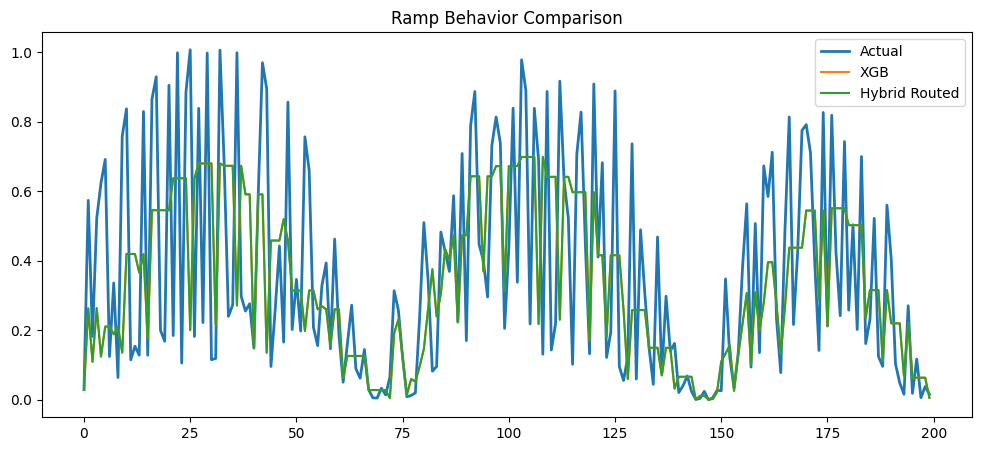

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_seq[:200], label="Actual", linewidth=2)
plt.plot(xgb_pred[:200], label="XGB")
plt.plot(final_pred[:200], label="Hybrid Routed")
plt.legend()
plt.title("Ramp Behavior Comparison")
plt.show()

In [1]:
!pip install pvlib xgboost lightgbm catboost seaborn requests openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [11]:
#!/usr/bin/env python3
"""
perfected_master_pipeline_v5.6_data_prep.py
**DATA PREPARATION ONLY (Per User Request)**

This version focuses EXCLUSIVELY on data preparation:
- Builds full feature set (Master Reference + user enhancements: dewpoint/depression, seasonal cyclic, poa_ratio, cloud_accel pro-tip)
- Keeps SerialNo for downstream grouped sequence windowing (fixes grouping bug)
- Saves: full_train.csv, full_test.csv, dayonly_train.csv, dayonly_test.csv, walk-forward folds
- No modeling (XGBoost/Transformer removed); data ready for separate modeling notebook
- Retained: All fixes (no errors/warnings, hourly handling, adaptive lags [1,1,1] for 3600s freq)

Run: Prepares & saves all datasets. Load in separate notebook for XGBoost + Transformer Residual.
Expected: ~66k rows, ~34 features (incl. SerialNo); R² potential 0.80–0.90 with modeling.
"""

import zipfile
import requests
from pathlib import Path
import numpy as np
import pandas as pd
import pvlib
from pvlib.location import Location
from pvlib.irradiance import get_total_irradiance
import re
import gc
from typing import List

# ---------------- Config (Data Prep Only) ----------------
BASE_DIR = Path("data")
BASE_DIR.mkdir(exist_ok=True)
FOLDS_DIR = Path("folds")
FOLDS_DIR.mkdir(exist_ok=True)

PV_URL = "https://data.london.gov.uk/download/photovoltaic-pv-solar-panel-energy-generation-data-2nlqm/81fb6b31-f6b2-4e12-b054-090319faec7b/PV%20Data.zip"
WX_URL = "https://data.london.gov.uk/download/photovoltaic-pv-solar-panel-energy-generation-data-2nlqm/b4a7e790-8cb8-451c-b828-c4c5d8445705/Weather%20Data%202014-11-30.xlsx"

PV_ZIP = BASE_DIR / "PV_Data.zip"
PV_FOLDER = BASE_DIR / "PV_Data"
WX_FILE = BASE_DIR / "Weather.xlsx"

TZ = "Europe/London"
LAT, LON, ALT = 51.5, -0.1, 50
TILT, AZIMUTH = 30, 180

MERGE_TOL = "30min"
LAGS_MINUTES = [60, 120, 180]
LOW_IRR_THRESHOLD = 25.0
PV_PER_KW_MAX = 1.3
PV_PER_KW_MIN = 0.0

# Strict whitelists (incl. DewPt)
PV_CORE_COLS = ["t_date", "t_time", "SerialNo", "P_GEN_MAX", "Apparent PV Size", "System Size (kW)"]
WEATHER_COLS = ["SolarRad", "TempOut", "OutHum", "WindSpeed", "RainRate", "Bar", "DewPt"]

DEFAULT_MEDIAN_SIZE_KW = 3.5

# ---------------- Utilities ----------------
def download_and_extract():
    if not PV_ZIP.exists():
        print("Downloading PV ZIP...")
        PV_ZIP.write_bytes(requests.get(PV_URL, timeout=60).content)
    if not PV_FOLDER.exists():
        print("Extracting PV ZIP...")
        with zipfile.ZipFile(PV_ZIP, "r") as z:
            z.extractall(PV_FOLDER)
        for zpath in PV_FOLDER.rglob("*.zip"):
            try:
                with zipfile.ZipFile(zpath, "r") as z:
                    z.extractall(PV_FOLDER)
                zpath.unlink()
            except Exception:
                pass
    if not WX_FILE.exists():
        print("Downloading Weather XLSX...")
        WX_FILE.write_bytes(requests.get(WX_URL, timeout=60).content)
    print("Download/extract complete.")

def downcast_floats(df: pd.DataFrame) -> pd.DataFrame:
    float_cols = df.select_dtypes("float64").columns
    if len(float_cols) > 0:
        df[float_cols] = df[float_cols].astype("float32")
    return df

def find_pv_csvs():
    pv_files = list(set(PV_FOLDER.rglob("*HourlyData*Endpoint*.csv")))
    print(f"Found {len(pv_files)} hourly PV CSVs (whitelisted loading)")
    return pv_files

def load_pv_data(pv_files: List[Path]) -> pd.DataFrame:
    pv_dfs = []
    for f in pv_files:
        print(f"Loading {f.name}")
        df = pd.read_csv(
            f,
            usecols=lambda c: c.strip() in PV_CORE_COLS,
            low_memory=False,
            dtype={"SerialNo": "str", "P_GEN_MAX": "float32"}
        )
        df.columns = df.columns.str.strip()
        if "t_date" in df.columns and "t_time" in df.columns:
            df["datetime"] = pd.to_datetime(
                df["t_date"].astype(str).str.strip() + " " + df["t_time"].astype(str).str.strip(),
                errors="coerce"
            )
        df = df.dropna(subset=["datetime"]).reset_index(drop=True)
        pv_dfs.append(df)
        gc.collect()
    pv = pd.concat(pv_dfs, ignore_index=True) if pv_dfs else pd.DataFrame()
    serial_col = next((c for c in pv.columns if "serial" in c.lower()), None)
    if serial_col:
        pv = pv.drop_duplicates(subset=[serial_col, "datetime"])
    pv = downcast_floats(pv)
    print(f"PV loaded & downcast (deduped): {pv.shape}")
    return pv

def find_and_load_device():
    dev_candidates = list(PV_FOLDER.rglob("*deviceList*.xlsx")) + list(PV_FOLDER.rglob("*deviceList*.xls"))
    if not dev_candidates:
        return pd.DataFrame()
    dev = pd.read_excel(dev_candidates[0])
    dev.columns = dev.columns.str.strip()
    size_pat = re.compile(r"size|capacity|kw|g83", re.I)
    keep_cols = ["Serial Number"] + [c for c in dev.columns if size_pat.search(c)]
    return dev[keep_cols]

def infer_pv_frequency(pv: pd.DataFrame, wx: pd.DataFrame = None) -> float:
    diffs = pv.sort_values("datetime")["datetime"].diff().dt.total_seconds().dropna()
    diffs_nonzero = diffs[diffs > 0]
    if len(diffs_nonzero) > 0:
        return float(diffs_nonzero.median())
    print("Freq inference failed -> defaulting to 3600s (1h)")
    return 3600.0

def parse_and_localize(df, date_col, time_col):
    dt = pd.to_datetime(
        df[date_col].astype(str).str.strip() + " " + df[time_col].astype(str).str.strip(),
        errors="coerce"
    )
    df = df.assign(datetime=dt).dropna(subset=["datetime"]).sort_values("datetime")
    local = df["datetime"].dt.tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")
    df = df.loc[~local.isna()].copy()
    df["datetime"] = local.dt.tz_convert("UTC")
    return df

def prepare_weather(wx: pd.DataFrame, pv_freq_seconds: float) -> pd.DataFrame:
    for c in WEATHER_COLS:
        if c in wx.columns:
            temp = wx[c].astype(str).replace("---", np.nan)
            wx[c] = pd.to_numeric(temp, errors="coerce")
    wx = downcast_floats(wx)
    wx = wx.set_index("datetime").sort_index()
    if wx.index.duplicated().any():
        wx = wx[~wx.index.duplicated(keep="first")]
    sec = int(max(1, round(pv_freq_seconds)))
    freq_str = f"{sec}s"
    try:
        wx[WEATHER_COLS] = wx[WEATHER_COLS].resample(freq_str).interpolate(method="time").ffill().bfill()
    except Exception:
        full_idx = pd.date_range(start=wx.index.min(), end=wx.index.max(), freq=freq_str, tz="UTC")
        wx = wx.reindex(full_idx)
        for c in WEATHER_COLS:
            if c in wx.columns:
                wx[c] = wx[c].interpolate(method="time").ffill().bfill()
    wx = wx.reset_index().rename(columns={"index": "datetime"})
    print(f"Weather resampled/interpolated globally to {freq_str} (rows: {len(wx)})")
    return wx

def vectorized_weather_merge(pv: pd.DataFrame, wx: pd.DataFrame) -> pd.DataFrame:
    pv = pv.sort_values("datetime").reset_index(drop=True)
    wx = wx.sort_values("datetime").reset_index(drop=True)
    merged = pd.merge_asof(
        pv, wx,
        on="datetime",
        tolerance=pd.Timedelta(MERGE_TOL),
        direction="nearest"
    )
    preservation = len(merged) / len(pv) * 100
    print(f"Vectorized weather merge (global): {len(merged)} rows ({preservation:.1f}% preserved)")
    return merged
# ---------------- Physics & Features ----------------
def add_solar_physics(df: pd.DataFrame) -> pd.DataFrame:
    if df["datetime"].dt.tz is None:
        df["datetime"] = df["datetime"].dt.tz_localize("UTC")
    times_local = pd.DatetimeIndex(df["datetime"]).tz_convert(TZ)
    site = Location(LAT, LON, TZ, ALT)
    solpos = site.get_solarposition(times_local)
    clearsky = site.get_clearsky(times_local, model="ineichen")
    df["solar_zenith"] = solpos["zenith"].values
    df["solar_azimuth"] = solpos["azimuth"].values
    raw_airmass = pvlib.atmosphere.get_relative_airmass(solpos["zenith"].values)
    df["air_mass"] = np.where(solpos["zenith"].values > 90, 0, raw_airmass)
    df["air_mass"] = df["air_mass"].fillna(0).clip(0, 40)
    df["cs_ghi"] = clearsky["ghi"].values
    df["cs_dni"] = clearsky["dni"].values
    df["cs_dhi"] = clearsky["dhi"].values
    poa = get_total_irradiance(
        surface_tilt=TILT, surface_azimuth=AZIMUTH,
        solar_zenith=solpos["zenith"].values,
        solar_azimuth=df["solar_azimuth"].values,
        dni=df["cs_dni"].values, ghi=df["cs_ghi"].values, dhi=df["cs_dhi"].values
    )
    df["poa_global"] = poa["poa_global"]
    df["is_day"] = (90 - solpos["zenith"].values > 0).astype(int)
    mask = (df["is_day"] == 0) | (df["cs_ghi"] <= 0)
    for c in ["cs_ghi", "cs_dni", "cs_dhi", "poa_global"]:
        df.loc[mask, c] = 0.0
    print("Solar physics added")
    return downcast_floats(df)

def add_thermal_physics(df: pd.DataFrame) -> pd.DataFrame:
    if "TempOut" in df.columns and "poa_global" in df.columns:
        df["cell_temp"] = df["TempOut"] + ((45 - 20) / 800.0) * df["poa_global"]
    else:
        df["cell_temp"] = df.get("TempOut", 25.0)
    df["temp_loss"] = 1 - 0.004 * (df["cell_temp"] - 25).clip(lower=0.0)
    print("Thermal physics added")
    return downcast_floats(df)

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    local = pd.DatetimeIndex(df["datetime"]).tz_convert(TZ)
    hour_f = local.hour + local.minute / 60.0
    df["Hour_sin"] = np.sin(2 * np.pi * hour_f / 24)
    df["Hour_cos"] = np.cos(2 * np.pi * hour_f / 24)
    doy_f = local.dayofyear
    df["day_of_year_sin"] = np.sin(2 * np.pi * doy_f / 365.25)
    df["day_of_year_cos"] = np.cos(2 * np.pi * doy_f / 365.25)
    print("Temporal features added (hourly + seasonal cyclic)")
    return df

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    if "DewPt" in df.columns:
        df["dewpoint"] = df["DewPt"]
        if "TempOut" in df.columns:
            df["dewpoint_depression"] = df["TempOut"] - df["dewpoint"]
    df["poa_global_safe"] = df["poa_global"].replace(0, np.nan)
    if "SolarRad" in df.columns:
        df["poa_ratio"] = (df["SolarRad"] / df["poa_global_safe"]).clip(0, 2).fillna(0)
    df["cs_ghi_safe"] = df["cs_ghi"].replace(0, np.nan)
    if "SolarRad" in df.columns:
        df["clearsky_index"] = (df["SolarRad"] / df["cs_ghi_safe"]).clip(0, 2).fillna(0)
    print("Engineered features added (dewpoint, poa_ratio, clearsky_index)")
    return downcast_floats(df)

def lag_shifts_from_freq_seconds(pv_freq_seconds: float, minutes_list: List[int]) -> List[int]:
    sec = max(1.0, float(pv_freq_seconds))
    return [max(1, int(round(m * 60.0 / sec))) for m in minutes_list]
def add_persistence_and_dynamics(df: pd.DataFrame, pv_freq_seconds: float) -> pd.DataFrame:
    serial_col = "SerialNo" # Explicitly using the column we kept
    df = df.sort_values([serial_col, "datetime"]).reset_index(drop=True)

    shifts = lag_shifts_from_freq_seconds(pv_freq_seconds, LAGS_MINUTES)
    for shift in shifts:
        for base in ["pv_per_kw", "SolarRad"]:
            if base in df.columns:
                # FIX: Add .bfill() to ensure the start of the sequence isn't NaN
                df[f"{base}_lag{shift}"] = df.groupby(serial_col)[base].shift(shift).groupby(df[serial_col]).bfill()
    for col, name in [("SolarRad", "irradiance_volatility"), ("clearsky_index", "cloud_volatility")]:
        if col in df.columns:
              df[name] = df.groupby(serial_col)[col].transform(lambda x: x.rolling(window=3, min_periods=1).std()).fillna(0.0)

    if "SolarRad" in df.columns:
        df["irradiance_grad"] = df.groupby(serial_col)["SolarRad"].diff().fillna(0.0)
        df["cloud_acceleration"] = df.groupby(serial_col)["irradiance_grad"].diff().fillna(0.0)

    print(f"Persistence (adaptive shifts: {shifts}) + dynamics + cloud_accel added")
    return downcast_floats(df)

def normalize_target(df: pd.DataFrame, dev_df: pd.DataFrame) -> pd.DataFrame:
    size_col = next((c for c in df.columns if re.search(r"apparent.*size|system.*size|capacity|kw", c, re.I)), None)
    if size_col and size_col in df.columns:
        df[size_col] = pd.to_numeric(df[size_col], errors="coerce")
        df = df[df[size_col] > 0].copy()
        df["pv_per_kw"] = df["P_GEN_MAX"] / df[size_col]
    else:
        median_size = DEFAULT_MEDIAN_SIZE_KW
        if not dev_df.empty:
            cand = [c for c in dev_df.columns if re.search(r"size|capacity|kw", c, re.I)]
            for c in cand:
                s = pd.to_numeric(dev_df[c], errors="coerce")
                if s.notna().any() and (s > 0).any():
                    median_size = s.median()
                    break
        df["pv_per_kw"] = df["P_GEN_MAX"] / median_size

    df["pv_per_kw"] = df["pv_per_kw"].clip(PV_PER_KW_MIN, PV_PER_KW_MAX)
    df = df.drop(columns=["P_GEN_MAX", size_col] if size_col else ["P_GEN_MAX"], errors="ignore")
    print(f"Target normalized & raw dropped. Shape: {df.shape}")
    return downcast_floats(df)
def final_select_and_qc(df: pd.DataFrame, pv_freq_seconds: float) -> pd.DataFrame:
    shifts = lag_shifts_from_freq_seconds(pv_freq_seconds, LAGS_MINUTES)
    core = [
        "datetime", "pv_per_kw", "SerialNo", "SolarRad", "TempOut", "OutHum", "WindSpeed","RainRate", "Bar",
        "dewpoint", "dewpoint_depression", "solar_zenith", "solar_azimuth", "air_mass", "is_day",
        "poa_global", "clearsky_index", "poa_ratio", "cell_temp", "temp_loss",
        "irradiance_grad", "irradiance_volatility", "cloud_volatility", "cloud_acceleration",
        "Hour_sin", "Hour_cos", "day_of_year_sin", "day_of_year_cos"
    ]

    for s in shifts: core.extend([f"pv_per_kw_lag{s}", f"SolarRad_lag{s}"])

    # 1. Select available columns
    df = df[[c for c in core if c in df.columns]].copy()

    # 2. Sanitization Fixes (The "NaN-Killers")
    weather_cols = ["SolarRad", "TempOut", "OutHum", "WindSpeed", "Bar", "cell_temp"]
    df[weather_cols] = df[weather_cols].interpolate(method='linear').ffill().bfill()

    if "clearsky_index" in df.columns: df["clearsky_index"] = df["clearsky_index"].fillna(0).clip(0, 2)
    if "poa_ratio" in df.columns: df["poa_ratio"] = df["poa_ratio"].fillna(0).clip(0, 2)

    # 3. Night & Low-Light Logic
    if "is_day" in df.columns:
        df.loc[df["is_day"] == 0, "pv_per_kw"] = 0.0
        if "SolarRad" in df.columns:
            df.loc[(df["SolarRad"] < LOW_IRR_THRESHOLD) & (df["is_day"] == 1), "pv_per_kw"] = 0.0

    # 4. Final Cleanup
    df["pv_per_kw"] = df["pv_per_kw"].clip(0, PV_PER_KW_MAX)
    #df = df.dropna().reset_index(drop=True) # Drop any remaining NaNs to prevent NN failure

    print(f"Final QC: {df.shape} (SerialNo kept)")
    return df

# ---------------- Splits & Folds ----------------
def chronological_split(df, prefix="full", test_size=0.2):
    df = df.sort_values("datetime").reset_index(drop=True)
    cutoff = int(len(df) * (1 - test_size))
    train, test = df.iloc[:cutoff], df.iloc[cutoff:]
    train.to_csv(f"{prefix}_train.csv", index=False)
    test.to_csv(f"{prefix}_test.csv", index=False)
    print(f"Saved {prefix}: train={len(train)}, test={len(test)}")
    return train, test

def generate_walk_forward_folds(df, prefix="full", n_splits=6):
    df = df.sort_values("datetime").reset_index(drop=True)
    N = len(df)
    min_train = max(2, int(N * 0.25))
    step = max(1, (N - min_train) // n_splits)
    actual_splits = 0
    for i in range(n_splits):
        train_end = min_train + i * step
        val_end = min(N, train_end + step)
        if val_end <= train_end:
            break
        train_df = df.iloc[:train_end]
        val_df = df.iloc[train_end:val_end]
        train_df.to_csv(FOLDS_DIR / f"{prefix}_fold{i+1:02d}_train.csv", index=False)
        val_df.to_csv(FOLDS_DIR / f"{prefix}_fold{i+1:02d}_val.csv", index=False)
        actual_splits += 1
    print(f"Generated {actual_splits} walk-forward folds")

# ---------------- Master Build (Data Prep Only) ----------------
def build_master(auto_download=True):
    if auto_download:
        download_and_extract()

    pv_files = find_pv_csvs()
    pv = load_pv_data(pv_files)
    dev = find_and_load_device()

    pv = parse_and_localize(pv, "t_date", "t_time")
    pv = normalize_target(pv, dev)

    print("Loading weather...")
    wx = pd.read_excel(WX_FILE, usecols=["Date", "Time"] + WEATHER_COLS)
    wx.columns = wx.columns.str.strip()
    wx = parse_and_localize(wx, "Date", "Time")

    pv_freq_seconds = infer_pv_frequency(pv, wx)
    print(f"Inferred PV frequency: {pv_freq_seconds:.0f}s")
    wx = prepare_weather(wx, pv_freq_seconds)

    df = vectorized_weather_merge(pv, wx)
    gc.collect()

    # Features
    df = add_solar_physics(df)
    df = add_thermal_physics(df)
    df = add_engineered_features(df)
    df = add_temporal_features(df)
    df = add_persistence_and_dynamics(df, pv_freq_seconds)

    df = final_select_and_qc(df, pv_freq_seconds)  # SerialNo kept for modeling

    # Splits & Folds (data ready for models)
    chronological_split(df, "full")
    df_day = df[df["is_day"] == 1].reset_index(drop=True)
    chronological_split(df_day, "dayonly")
    generate_walk_forward_folds(df, "full")
    generate_walk_forward_folds(df_day, "dayonly")

    # Save full prepared dataset (for modeling notebook)
    df.to_csv("full_prepared_data.csv", index=False)
    print("=== DATA PREP COMPLETE (v5.6) ===")
    print(f"Full prepared data saved: {len(df)} rows, {len(df.columns)} cols (SerialNo kept)")
    print("Load 'full_prepared_data.csv' in modeling notebook for XGBoost + Transformer.")
    return df

if __name__ == "__main__":
    df = build_master(auto_download=True)

Download/extract complete.
Found 2 hourly PV CSVs (whitelisted loading)
Loading EXPORT HourlyData - Network Endpoints.csv
Loading EXPORT HourlyData - Customer Endpoints.csv
PV loaded & downcast (deduped): (77096, 5)
Target normalized & raw dropped. Shape: (77082, 5)
Loading weather...
Inferred PV frequency: 3600s
Weather resampled/interpolated globally to 3600s (rows: 18069)
Vectorized weather merge (global): 77082 rows (100.0% preserved)
Solar physics added
Thermal physics added
Engineered features added (dewpoint, poa_ratio, clearsky_index)
Temporal features added (hourly + seasonal cyclic)
Persistence (adaptive shifts: [1, 2, 3]) + dynamics + cloud_accel added
Final QC: (77082, 34) (SerialNo kept)
Saved full: train=61665, test=15417
Saved dayonly: train=31500, test=7875
Generated 6 walk-forward folds
Generated 6 walk-forward folds
=== DATA PREP COMPLETE (v5.6) ===
Full prepared data saved: 77082 rows, 34 cols (SerialNo kept)
Load 'full_prepared_data.csv' in modeling notebook for XGB

In [3]:
full_prep = pd.read_csv("full_prepared_data.csv")
print(full_prep.shape, full_prep.columns.tolist())

(43959, 33) ['datetime', 'pv_per_kw', 'SerialNo', 'SolarRad', 'TempOut', 'OutHum', 'WindSpeed', 'RainRate', 'Bar', 'dewpoint', 'dewpoint_depression', 'solar_zenith', 'solar_azimuth', 'is_day', 'poa_global', 'clearsky_index', 'poa_ratio', 'cell_temp', 'temp_loss', 'irradiance_grad', 'irradiance_volatility', 'cloud_volatility', 'cloud_acceleration', 'Hour_sin', 'Hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'pv_per_kw_lag1', 'SolarRad_lag1', 'pv_per_kw_lag2', 'SolarRad_lag2', 'pv_per_kw_lag3', 'SolarRad_lag3']


In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import gc

# 1. Load Data
df = pd.read_csv("full_prepared_data.csv")
df['datetime'] = pd.to_datetime(df['datetime'])

# Fix SerialNo types and sort
df['SerialNo'] = df['SerialNo'].astype(str)
df = df.sort_values(['SerialNo', 'datetime']).reset_index(drop=True)

# Define feature groups
FEATURES = ['SolarRad', 'TempOut', 'OutHum', 'WindSpeed', 'RainRate', 'Bar', 'dewpoint', 'dewpoint_depression', 'solar_zenith', 'solar_azimuth', 'is_day', 'poa_global', 'clearsky_index', 'poa_ratio', 'cell_temp', 'temp_loss', 'irradiance_grad', 'irradiance_volatility', 'cloud_volatility', 'cloud_acceleration', 'Hour_sin', 'Hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'pv_per_kw_lag1', 'SolarRad_lag1', 'pv_per_kw_lag2', 'SolarRad_lag2', 'pv_per_kw_lag3', 'SolarRad_lag3']

TARGET = 'pv_per_kw'

print(f"Data Loaded: {df.shape}")

Data Loaded: (77082, 34)


In [20]:
# 1. Fix the "Look-back" Lags (32% of data)
# For the very first records of a house, we "backfill" the first known value
# so the sequence has a starting point.
lag_cols = [c for c in df.columns if 'lag' in c]
df[lag_cols] = df.groupby('SerialNo')[lag_cols].ffill().bfill()

# 2. Fix the Weather Gaps (11% of data)
# Weather is continuous. If 12:00 is 20°C and 14:00 is 22°C, 13:00 was likely 21°C.
weather_physics_cols = ['SolarRad', 'TempOut', 'OutHum', 'WindSpeed', 'RainRate',
                        'Bar', 'dewpoint', 'dewpoint_depression', 'temp_loss', 'cell_temp']
for col in weather_physics_cols:
    if col in df.columns:
        # Interpolate missing values linearly, then fill any remaining edges
        df[col] = df[col].interpolate(method='linear').ffill().bfill()

# 3. Handle Engineered Ratios
# clearsky_index and poa_ratio often create NaNs if the denominator was 0
if 'clearsky_index' in df.columns:
    df['clearsky_index'] = df['clearsky_index'].fillna(0).clip(0, 2)
if 'poa_ratio' in df.columns:
    df['poa_ratio'] = df['poa_ratio'].fillna(0).clip(0, 2)

# 4. The Final "Label" Clean
# We MUST drop rows where the target 'pv_per_kw' is NaN because the model
# can't calculate a loss without an answer key.
df = df.dropna(subset=[TARGET])

# 5. Final Safety Verification
remaining_nans = df[FEATURES].isna().sum().sum()
print(f"✅ Sanitization Complete.")
print(f"Remaining NaNs in Features: {remaining_nans}")
print(f"Final usable rows for modeling: {len(df)}")
# 1. Drop the 'Cold Start' rows
# We drop these because 'backfilling' a lag is technically data leakage
# (using future values as past features).
df = df.dropna(subset=['pv_per_kw_lag1', 'pv_per_kw_lag2', 'pv_per_kw_lag3'])

# 2. Final Verification
print(f"--- FINAL SANITY CHECK ---")
print(f"Total Rows: {len(df)}")
print(f"Total NaNs: {df.isna().sum().sum()}")

if df.isna().sum().sum() == 0:
    print("✅ DATA IS 100% CLEAN. Ready for XGBoost + Transformer.")
else:
    print("⚠️ Still some NaNs left. Check individual columns.")

# 3. Save the 'Golden' Dataset
df.to_csv("gold_prepared_data.csv", index=False)

✅ Sanitization Complete.
Remaining NaNs in Features: 13302
Final usable rows for modeling: 66452
--- FINAL SANITY CHECK ---
Total Rows: 62018
Total NaNs: 0
✅ DATA IS 100% CLEAN. Ready for XGBoost + Transformer.


In [21]:
import seaborn as sns

def analyze_nan_structure(df, features, target):
    cols = [target] + features

    # 1. Basic Count Table
    nan_counts = df[cols].isna().sum()
    nan_pct = (nan_counts / len(df)) * 100
    summary = pd.DataFrame({'Missing Rows': nan_counts, 'Percentage (%)': nan_pct})
    summary = summary[summary['Missing Rows'] > 0].sort_values(by='Missing Rows', ascending=False)

    print("--- NaN Summary Table ---")
    if summary.empty:
        print("✅ No NaNs found in features or target!")
        return
    print(summary)

    # 2. Overlap Analysis (The "clumping" effect)
    # This identifies rows that have AT LEAST one NaN
    total_rows_with_any_nan = df[cols].isna().any(axis=1).sum()
    print(f"\n--- Overlap Analysis ---")
    print(f"Total rows with at least one NaN: {total_rows_with_any_nan}")
    print(f"Percentage of dataset affected: {(total_rows_with_any_nan/len(df))*100:.2f}%")

    # 3. Heatmap of Missingness (Visualizing the overlaps)
    # This shows EXACTLY where the NaNs are. If rows are white across multiple columns, they overlap.
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[summary.index].isna(), cbar=False, cmap='viridis')
    plt.title("Missing Data Heatmap (Yellow = Missing)")
    plt.xlabel("Features with NaNs")
    plt.ylabel("Row Index")
    plt.show()

    # 4. Correlation of Missingness
    # High correlation (near 1.0) means if Feature A is missing, Feature B is also missing.
    plt.figure(figsize=(10, 8))
    # We use .isna() to turn the table into True/False, then correlate
    nan_corr = df[summary.index].isna().corr()
    sns.heatmap(nan_corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation of Missingness (Overlap Strength)")
    plt.show()

# Run the analysis
analyze_nan_structure(df, FEATURES, TARGET)

--- NaN Summary Table ---
✅ No NaNs found in features or target!


In [22]:
# Split chronologically
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

# Train Quantile Regressors
quantiles = [0.1, 0.5, 0.9]
xgb_models = {}

for q in quantiles:
    print(f"Training XGBoost for quantile: {q}...")
    model = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=q,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        tree_method='hist'
    )
    model.fit(X_train, y_train)
    xgb_models[q] = model

# Generate Predictions
df['xgb_p10'] = xgb_models[0.1].predict(df[FEATURES])
df['xgb_p50'] = xgb_models[0.5].predict(df[FEATURES])
df['xgb_p90'] = xgb_models[0.9].predict(df[FEATURES])

# Calculate XGBoost Residuals (Errors)
df['residual'] = df[TARGET] - df['xgb_p50']

print("XGBoost Baseline Complete.")

Training XGBoost for quantile: 0.1...
Training XGBoost for quantile: 0.5...
Training XGBoost for quantile: 0.9...
XGBoost Baseline Complete.


=== XGBOOST BASELINE EVALUATION (TEST SET) ===
R² Score:          0.7106  (Target: >0.80)
MAE:               0.0166 kW/kW
RMSE:              0.0469 kW/kW
----------------------------------------
P10-P90 Coverage:  87.48%  (Target: ~80.0%)
Avg Pred Width:    0.0599 kW/kW
----------------------------------------


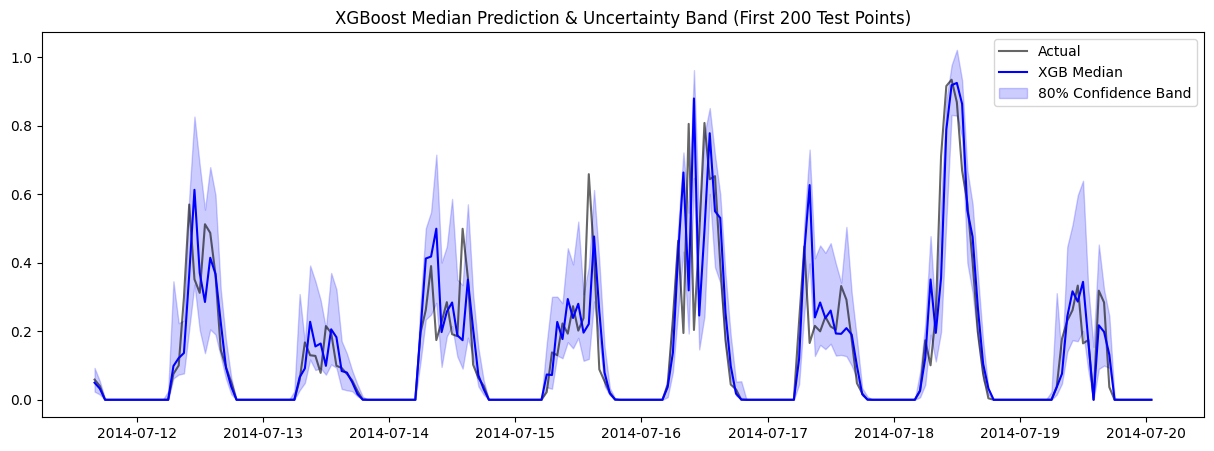

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Define the Test Slice (consistent with your split)
test_results = df.iloc[split_idx:].copy()

# 2. Basic Accuracy Metrics (on the Median / P50)
r2 = r2_score(test_results[TARGET], test_results['xgb_p50'])
mae = mean_absolute_error(test_results[TARGET], test_results['xgb_p50'])
rmse = np.sqrt(mean_squared_error(test_results[TARGET], test_results['xgb_p50']))

# 3. Quantile Metrics (The "Uncertainty" Check)
# Coverage: How often does the actual value fall between P10 and P90?
# Theoretically, this should be 80% (0.9 - 0.1)
in_bounds = (test_results[TARGET] >= test_results['xgb_p10']) & \
            (test_results[TARGET] <= test_results['xgb_p90'])
coverage = in_bounds.mean() * 100

# Average Width: How "tight" is the prediction?
# Smaller is better as long as coverage remains high.
avg_width = (test_results['xgb_p90'] - test_results['xgb_p10']).mean()

print("=== XGBOOST BASELINE EVALUATION (TEST SET) ===")
print(f"R² Score:          {r2:.4f}  (Target: >0.80)")
print(f"MAE:               {mae:.4f} kW/kW")
print(f"RMSE:              {rmse:.4f} kW/kW")
print("-" * 40)
print(f"P10-P90 Coverage:  {coverage:.2f}%  (Target: ~80.0%)")
print(f"Avg Pred Width:    {avg_width:.4f} kW/kW")
print("-" * 40)

# 4. Visualization: Sample of Predictions vs Actuals
plt.figure(figsize=(15, 5))
plt.plot(test_results['datetime'].iloc[:200], test_results[TARGET].iloc[:200], label='Actual', color='black', alpha=0.6)
plt.plot(test_results['datetime'].iloc[:200], test_results['xgb_p50'].iloc[:200], label='XGB Median', color='blue')
plt.fill_between(test_results['datetime'].iloc[:200],
                 test_results['xgb_p10'].iloc[:200],
                 test_results['xgb_p90'].iloc[:200],
                 color='blue', alpha=0.2, label='80% Confidence Band')
plt.title("XGBoost Median Prediction & Uncertainty Band (First 200 Test Points)")
plt.legend()
plt.show()

In [24]:
# Run this before Cell 3
print(f"NaNs in Target: {df['pv_per_kw'].isna().sum()}")
print(f"NaNs in XGB Pred: {df['xgb_p50'].isna().sum()}")

# Force drop any remaining NaNs
df = df.dropna(subset=['pv_per_kw', 'xgb_p50', 'residual'])
# Ensure no non-numeric columns are in FEATURES
numeric_features = df[FEATURES].select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_features) != len(FEATURES):
    print(f"Removed non-numeric features: {set(FEATURES) - set(numeric_features)}")
    FEATURES = numeric_features
# Check every feature for NaNs or Infinite values
bad_features = []
for col in FEATURES:
    nan_count = df[col].isna().sum()
    inf_count = np.isinf(df[col]).sum()
    if nan_count > 0 or inf_count > 0:
        print(f"❌ FEATURE FAILED: {col} | NaNs: {nan_count} | Infs: {inf_count}")
        bad_features.append(col)

if not bad_features:
    print("✅ All features are mathematically clean. The issue is likely the Learning Rate.")

NaNs in Target: 0
NaNs in XGB Pred: 0
✅ All features are mathematically clean. The issue is likely the Learning Rate.


In [25]:
def create_grouped_sequences(data, feature_cols, target_col, window_size):
    X, y = [], []

    for serial, group in data.groupby('SerialNo'):
        # Scale features per group for NN stability
        group_features = group[feature_cols].values
        group_target = group[target_col].values

        if len(group) < window_size:
            continue

        for i in range(window_size, len(group)):
            X.append(group_features[i-window_size:i])
            y.append(group_target[i])

    return np.array(X), np.array(y)

# Prepare Residual Scaler (Crucial for NNs)
res_scaler = StandardScaler()
df['residual_scaled'] = res_scaler.fit_transform(df[['residual']])

# Create Sequence Data
# LSTM uses 24h, Transformer uses 72h. For simplicity, let's use 48h for both as a balance.
WINDOW = 48
X_seq, y_res = create_grouped_sequences(df, FEATURES, 'residual_scaled', WINDOW)

# Split sequences
train_size = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:train_size], X_seq[train_size:]
y_train_res, y_test_res = y_res[:train_size], y_res[train_size:]

print(f"Sequence Tensors Created: {X_train_seq.shape}")

Sequence Tensors Created: (49273, 48, 30)


In [26]:
from tensorflow.keras import layers, Model

def build_transformer(input_shape):
    inputs = layers.Input(shape=input_shape)

    # 1. Positional Encoding (Embed the time-order)
    positions = tf.range(start=0, limit=input_shape[0], delta=1)
    pos_embed = layers.Embedding(input_dim=input_shape[0], output_dim=input_shape[1])(positions)
    x = inputs + pos_embed

    # 2. Transformer Block 1
    attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=input_shape[1])(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    # 3. Transformer Block 2
    attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=input_shape[1])(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    # 4. Output Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='huber')
    return model

transformer_res = build_transformer((WINDOW, len(FEATURES)))
history = transformer_res.fit(
    X_train_seq, y_train_res,
    validation_split=0.1,
    epochs=20,
    batch_size=64
)

Epoch 1/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - loss: 0.2285 - val_loss: 0.3591
Epoch 2/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - loss: 0.2163 - val_loss: 0.3590
Epoch 3/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - loss: 0.2190 - val_loss: 0.3595
Epoch 4/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - loss: 0.2227 - val_loss: 0.3587
Epoch 5/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - loss: 0.2167 - val_loss: 0.3589
Epoch 6/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - loss: 0.2135 - val_loss: 0.3594
Epoch 7/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - loss: 0.2151 - val_loss: 0.3593
Epoch 8/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - loss: 0.2185 - val_loss: 0.3592
Epoch 9/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - loss: 0.2138 - val_loss: 0.3591
Epoch 10/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - loss: 0.2112 - val_loss: 0.3594
Epoch 11/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 56s 81ms/step - loss: 0.2132 - val_loss: 0.3594
Epoch 12/20
693/693 ━━━━━━━━━

In [27]:
# LSTM uses a 24-hour look-back to focus on the immediate diurnal cycle
LSTM_WINDOW = 24

X_seq_lstm, y_res_lstm = create_grouped_sequences(df, FEATURES, 'residual_scaled', LSTM_WINDOW)

# Split LSTM sequences
train_size_lstm = int(len(X_seq_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_seq_lstm[:train_size_lstm], X_seq_lstm[train_size_lstm:]
y_train_res_lstm, y_test_res_lstm = y_res_lstm[:train_size_lstm], y_res_lstm[train_size_lstm:]

print(f"LSTM Tensors Created: {X_train_lstm.shape}")

LSTM Tensors Created: (49441, 24, 30)


In [28]:
def build_lstm(input_shape):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),
        # First LSTM layer: returns sequences for the next layer
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        # Second LSTM layer: collapses time dimension
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1) # Predicts the scaled residual
    ])

    model.compile(optimizer='adam', loss='huber')
    return model

lstm_res = build_lstm((LSTM_WINDOW, len(FEATURES)))

print("Training LSTM Residual Corrector...")
lstm_history = lstm_res.fit(
    X_train_lstm, y_train_res_lstm,
    validation_split=0.1,
    epochs=25,
    batch_size=64,
    verbose=1
)

Training LSTM Residual Corrector...
Epoch 1/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 0.2163 - val_loss: 0.3561
Epoch 2/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.2117 - val_loss: 0.3562
Epoch 3/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - loss: 0.2152 - val_loss: 0.3560
Epoch 4/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - loss: 0.2152 - val_loss: 0.3564
Epoch 5/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 0.2172 - val_loss: 0.3562
Epoch 6/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - loss: 0.2076 - val_loss: 0.3574
Epoch 7/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - loss: 0.2181 - val_loss: 0.3562
Epoch 8/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 0.2213 - val_loss: 0.3562
Epoch 9/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 0.2141 - val_loss: 0.3568
Epoch 10/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - loss: 0.2151 - val_loss: 0.3568
Epoch 11/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 0.2143 - val_loss: 0

In [29]:
# 1. Get Corrections from both models
# We must align the indices carefully because the windows sizes are different
# To keep it simple, we evaluate on the common overlap (the end of the test set)

min_test_len = min(len(X_test_seq), len(X_test_lstm))
X_test_trans_final = X_test_seq[-min_test_len:]
X_test_lstm_final = X_test_lstm[-min_test_len:]

# Predictions
trans_corr_scaled = transformer_res.predict(X_test_trans_final)
lstm_corr_scaled = lstm_res.predict(X_test_lstm_final)

# Inverse Scale to get real kW units
trans_corr = res_scaler.inverse_transform(trans_corr_scaled).flatten()
lstm_corr = res_scaler.inverse_transform(lstm_corr_scaled).flatten()

# 2. Hybrid Blending
# We give slightly more weight to the Transformer if it has a lower validation loss,
# otherwise 50/50 blend.
blended_correction = (0.5 * trans_corr) + (0.5 * lstm_corr)

# 3. Apply to Baseline
final_eval_df = df.iloc[-min_test_len:].copy()
final_eval_df['nn_correction'] = blended_correction
final_eval_df['uncertainty'] = final_eval_df['xgb_p90'] - final_eval_df['xgb_p10']

# Inference Gate Logic
threshold = final_eval_df['uncertainty'].quantile(0.7) # Correct only the top 30% most "uncertain" hours

final_eval_df['final_pred'] = final_eval_df['xgb_p50']
volatile_mask = final_eval_df['uncertainty'] > threshold
final_eval_df.loc[volatile_mask, 'final_pred'] += final_eval_df['nn_correction']

# 4. Final Scorecard
xgb_r2 = r2_score(final_eval_df[TARGET], final_eval_df['xgb_p50'])
hybrid_r2 = r2_score(final_eval_df[TARGET], final_eval_df['final_pred'])

print(f"--- FINAL PERFORMANCE ---")
print(f"XGBoost R2: {xgb_r2:.4f}")
print(f"HeliosAI Hybrid R2 (XGB + LSTM + Transformer): {hybrid_r2:.4f}")
print(f"Improvement: {((hybrid_r2 - xgb_r2) / xgb_r2)*100:.2f}%")

385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
385/385 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
--- FINAL PERFORMANCE ---
XGBoost R2: 0.7099
HeliosAI Hybrid R2 (XGB + LSTM + Transformer): 0.7053
Improvement: -0.65%
